In [ ]:
# This python notebook serves for generating the data visualizations available in adjacent folders
# Author: Lukas Elias, xeliasl00
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Parse CSV files
files = [
    "all_asym_lb0_p1.csv",
    "all_asym_p1.csv",
    "all_asym_p05.csv",
    "all_single_road.csv",
    "all_sym_lb0_p1.csv",
    "all_sym_p1.csv",
    "all_sym_p05.csv",
]
cols = [
    "density",
    "left_flow",
    "right_flow",
    "avg_flow",
    "lane_change_per_site",
    "lane_change_per_car",
]

dfs = {}
for fname in files:
    csv_path = os.path.join(os.getcwd(), "<navigate to csv data folder>", fname)
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"CSV not found at {csv_path}")
    df_tmp = pd.read_csv(
        csv_path,
        header=None,
        names=cols,
        usecols=range(len(cols)),
        skipinitialspace=True,
        engine="python",
    )
    for c in cols:
        df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    stem = os.path.splitext(fname)[0]
    var_name = f"df_{stem}"
    globals()[var_name] = df_tmp
    dfs[stem] = df_tmp

print("Loaded DataFrames:", ", ".join(sorted(dfs.keys())))

Loaded DataFrames: all_asym_lb0_p1, all_asym_p05, all_asym_p1, all_single_road, all_sym_lb0_p1, all_sym_p05, all_sym_p1


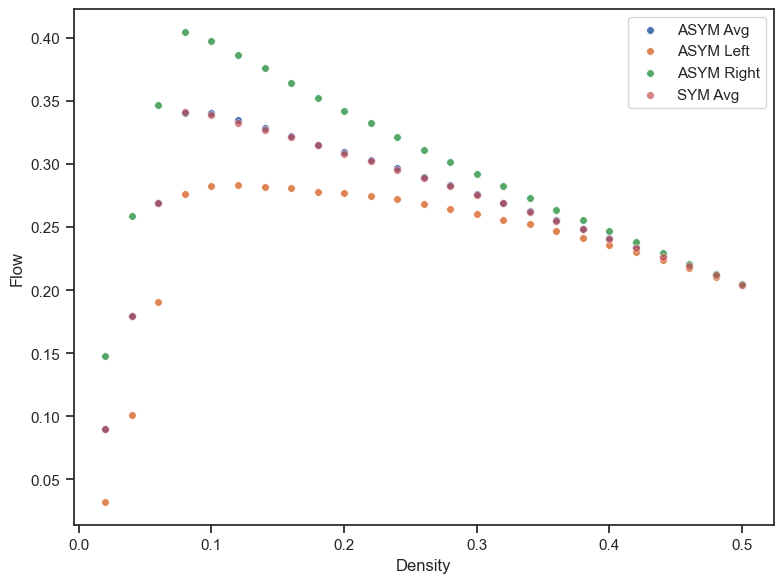

In [62]:
def plot_fig_3():
    df_asym = dfs["all_asym_p1"]
    df_sym = dfs["all_sym_p1"]

    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.scatterplot(ax=ax, data=df_asym, x="density", y="avg_flow", label="ASYM Avg", s=30)
    sns.scatterplot(ax=ax, data=df_asym, x="density", y="left_flow", label="ASYM Left", s=30)
    sns.scatterplot(ax=ax, data=df_asym, x="density", y="right_flow", label="ASYM Right", s=30)
    sns.scatterplot(ax=ax, data=df_sym, x="density", y="avg_flow", label="SYM Avg", s=30, alpha=0.7)

    ax.set_xlabel("Density")
    ax.set_ylabel("Flow")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figs_ims/fig3.png")
    plt.show()

plot_fig_3()

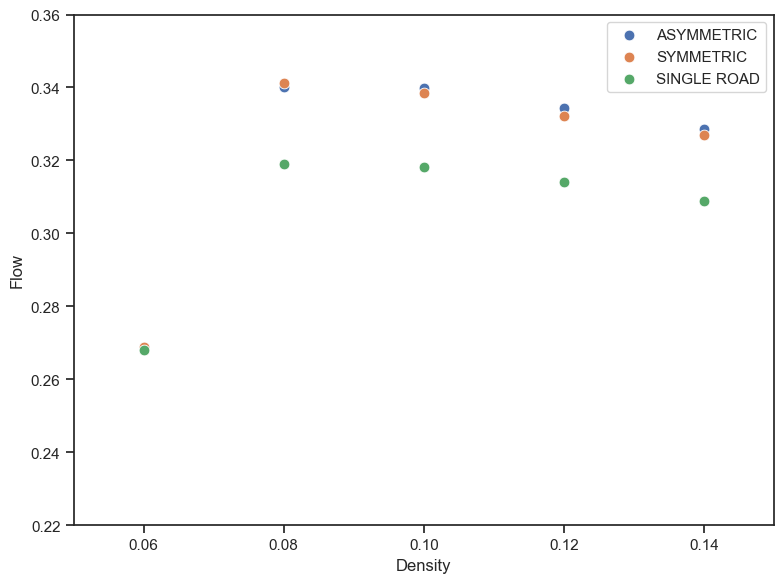

In [63]:
def plot_fig_4():
    df_asym = dfs["all_asym_p1"]
    df_sym = dfs["all_sym_p1"]
    df_single = dfs["all_single_road"]

    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.scatterplot(ax=ax, data=df_asym, x="density", y="avg_flow", label="ASYMMETRIC", s=60)
    sns.scatterplot(ax=ax, data=df_sym, x="density", y="avg_flow", label="SYMMETRIC", s=60)
    sns.scatterplot(ax=ax, data=df_single, x="density", y="left_flow", label="SINGLE ROAD", s=60)

    ax.set_xlim(0.05, 0.15)
    ax.set_ylim(0.22, 0.36)

    ax.set_xlabel("Density")
    ax.set_ylabel("Flow")
    ax.legend()

    plt.tight_layout()
    plt.savefig("figs_ims/fig4.png")
    plt.show()

plot_fig_4()

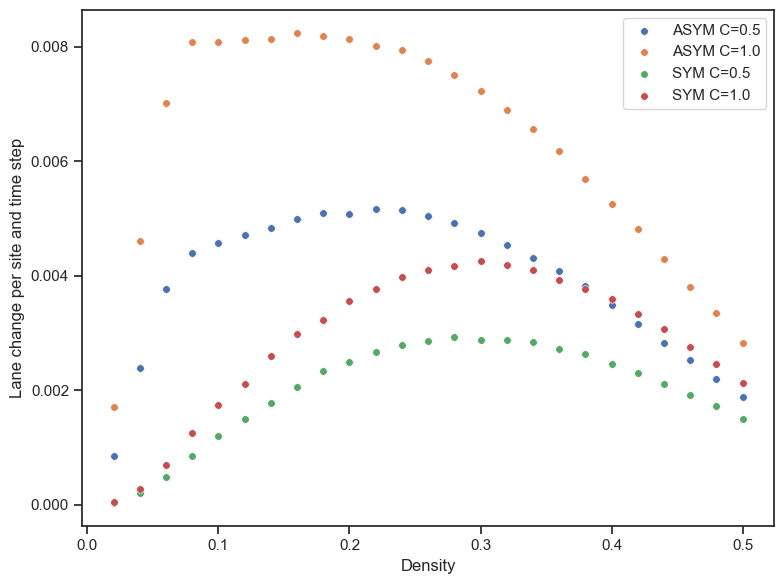

In [64]:
def plot_fig_5():
    df_asym = dfs["all_asym_p1"]
    df_sym = dfs["all_sym_p1"]
    df_asym_c5 = dfs["all_asym_p05"]
    df_sym_c5 = dfs["all_sym_p05"]

    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.scatterplot(ax=ax, data=df_asym_c5, x="density", y="lane_change_per_site", label="ASYM C=0.5", s=30)
    sns.scatterplot(ax=ax, data=df_asym, x="density", y="lane_change_per_site", label="ASYM C=1.0", s=30)
    sns.scatterplot(ax=ax, data=df_sym_c5, x="density", y="lane_change_per_site", label="SYM C=0.5", s=30)
    sns.scatterplot(ax=ax, data=df_sym, x="density", y="lane_change_per_site", label="SYM C=1.0", s=30)

    ax.set_xlabel("Density")
    ax.set_ylabel("Lane change per site and time step")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figs_ims/fig5.png")
    plt.show()
    

plot_fig_5()

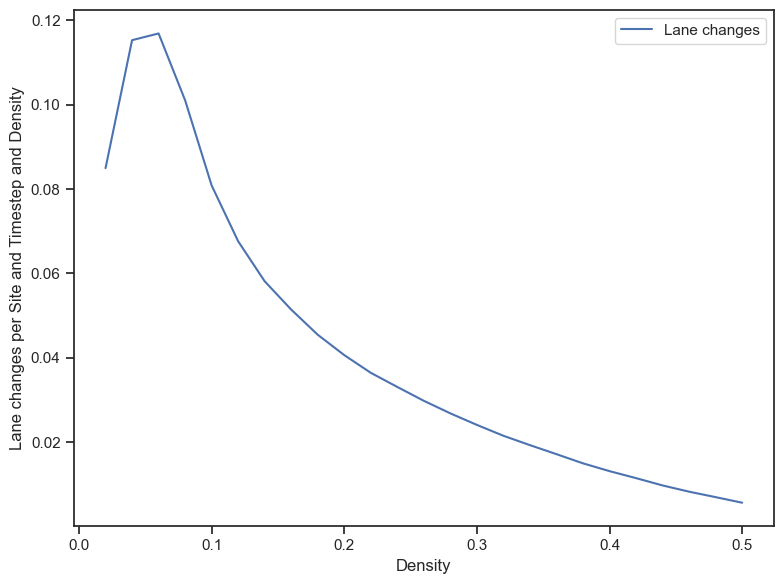

In [65]:
def plot_fig_6():
    df_asym = dfs["all_asym_p1"]

    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.lineplot(ax=ax, data=df_asym, x="density", y="lane_change_per_car", label="Lane changes")

    ax.set_xlabel("Density")
    ax.set_ylabel("Lane changes per Site and Timestep and Density")
    ax.legend()

    plt.tight_layout()
    plt.savefig("figs_ims/fig6.png")
    plt.show()


plot_fig_6()

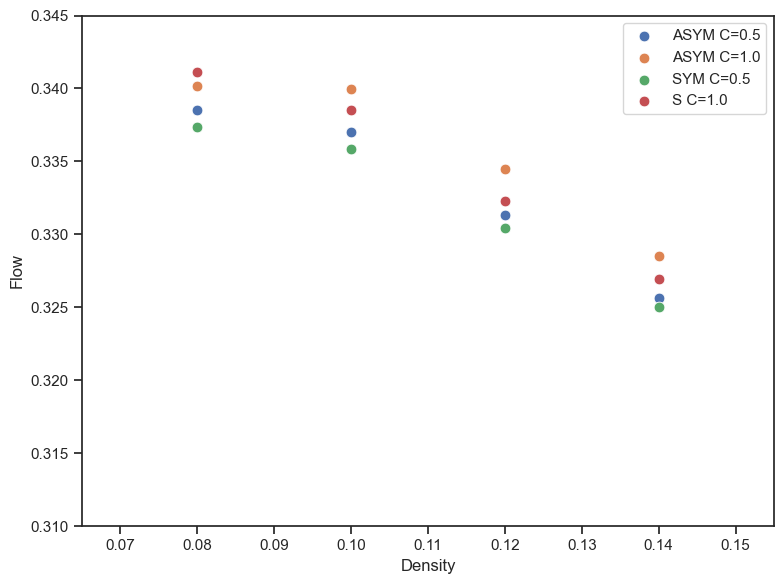

In [66]:
def plot_fig_7():
    df_asym = dfs["all_asym_p1"]
    df_sym = dfs["all_sym_p1"]
    df_asym05 = dfs["all_asym_p05"]
    df_sym05 = dfs["all_sym_p05"]


    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.scatterplot(ax=ax, data=df_asym05, x="density", y="avg_flow", label="ASYM C=0.5", s=60)
    sns.scatterplot(ax=ax, data=df_asym, x="density", y="avg_flow", label="ASYM C=1.0", s=60)
    sns.scatterplot(ax=ax, data=df_sym05, x="density", y="avg_flow", label="SYM C=0.5", s=60)
    sns.scatterplot(ax=ax, data=df_sym, x="density", y="avg_flow", label="S C=1.0", s=60)

    ax.set_xlim(0.065, 0.155)
    ax.set_ylim(0.31, 0.345)

    ax.set_xlabel("Density")
    ax.set_ylabel("Flow")
    ax.legend()

    plt.tight_layout()
    plt.savefig("figs_ims/fig7.png")
    plt.show()


plot_fig_7()

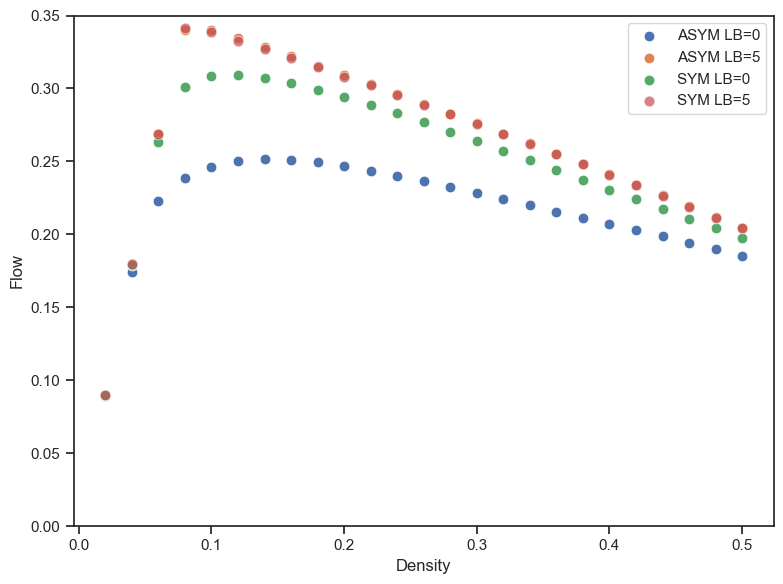

In [67]:
def plot_fig_11():
    df_asym = dfs["all_asym_p1"]
    df_sym = dfs["all_sym_p1"]
    df_asymlb0 = dfs["all_asym_lb0_p1"]
    df_symlb0 = dfs["all_sym_lb0_p1"]


    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))  # single figure with one axes

    sns.scatterplot(ax=ax, data=df_asymlb0, x="density", y="avg_flow", label="ASYM LB=0", s=60)
    sns.scatterplot(ax=ax, data=df_asym, x="density", y="avg_flow", label="ASYM LB=5", s=60)
    sns.scatterplot(ax=ax, data=df_symlb0, x="density", y="avg_flow", label="SYM LB=0", s=60)
    sns.scatterplot(ax=ax, data=df_sym, x="density", y="avg_flow", label="SYM LB=5", s=60, alpha=0.7)

    ax.set_xlabel("Density")
    ax.set_ylabel("Flow")
    ax.legend()

    ax.set_ylim(0, 0.35)

    plt.tight_layout()
    plt.savefig("figs_ims/fig11.png")
    plt.show()

plot_fig_11()